In [2]:
%reload_ext autoreload
%autoreload 2

import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["HDF5_USE_FILE_LOCKING"]= "FALSE"
    
from scipy.constants import mu_0
import manta as MaNTA

from objective2 import make_objective

import jax
import jax.numpy as jnp
import equinox as eqx 
import yancc

from yancc_wrapper2 import yancc_data

import desc
from desc import set_device
set_device("gpu")
import desc.io
from desc.equilibrium import Equilibrium, EquilibriaFamily
from desc.geometry import FourierRZToroidalSurface
from desc.grid import Grid, LinearGrid
from desc.plotting import plot_boozer_surface, plot_boundaries, plot_qs_error, plot_1d


from desc.objectives import (
    AspectRatio,
    FixBoundaryR,
    FixBoundaryZ,
    FixCurrent,
    FixPsi,
    ForceBalance,
    LinearObjectiveFromUser,
    ObjectiveFunction,
    ObjectiveFromUser,
    RotationalTransform,
    Volume,
)
from desc.profiles import SplineProfile
import matplotlib.pyplot as plt


Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/global/homes/e/eatocco/.conda/envs/desc-env/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 487, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/global/homes/e/eatocco/.conda/envs/desc-env/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 370, in initialize
    _check_cuda_versions(raise_on_first_error = True)
  File "/global/homes/e/eatocco/.conda/envs/desc-env/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:134: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Registering cpu implementation for operation get_solution
Registering gpu implementation for operation get_solution
Registering cpu implementation for operation get_adjoint_gradients
Registering gpu implementation for operation get_adjoint_gradients
Registering cpu implementation for operation run
Registering cpu implementation for operation run_ss
Using cache directory: /global/cfs/cdirs/mp217/eatocco/__pycache__
[CpuDevice(id=0)]


/global/cfs/cdirs/mp217/eatocco/DESC/desc/__init__.py:151: UserWarning: CUDA_VISIBLE_DEVICES= did not match any physical GPU (id=['0', '1', '2', '3']), falling back to CPU
  warnings.warn(


In [ ]:
from stellarator2 import StellaratorTransport
"""
---------------NOTEBOOK CONFIGURATION-----------------
"""
fname = "stellarator_opt"

eq_name = "eq3"

st_config = {
    "SourceCenter": 0.2,
    "SourceHeight": 150.0,
    "SourceWidth": 0.8,
    "EdgeTemperature": 0.2,
    "EdgeDensity": 0.2,
    "n0": 0.5,
}

rho_upper = 1.0
rtol = 1e-2
atol = 1e-3

# # %%
solver_config = {
    "OutputFilename": "stellarator_opt0",
    "Polynomial_degree": 3,
    "Grid_size": 4,
    "tau": 1.0,
    "Lower_boundary": 0.0,
    "Upper_boundary": rho_upper,
    "Relative_tolerance": rtol,
    "Absolute_tolerance": [atol],
    "delta_t": 1e-2,
    "initialTimestep": 1e-7,
    "MinStepSize": 1e-9,
    "SteadyStateTolerance": 1e-4,
    "restart": False,
    "solveAdjoint": True,
    "zeroFlux": True,
}


config = {
    "Stellarator": st_config,
    "Solver": solver_config,
}

points = MaNTA.getNodes(solver_config["Lower_boundary"], solver_config["Upper_boundary"],
                        solver_config["Grid_size"], solver_config["Polynomial_degree"])


yancc_rho = jnp.array(points)
yancc_ntheta = 17
yancc_nzeta = 33

yancc_res = {"na": 53, "nx": 5}

# to allow maximum flexibility to match manta, we use a spline with the same control points as manta \
# + axis and lcfs
# initial pressure is all zeros, can change this if desired

pressure_rho = jnp.concatenate([jnp.zeros(1), yancc_rho, jnp.ones(1)])
desc_pressure = SplineProfile(jnp.zeros_like(pressure_rho), pressure_rho)

surf = FourierRZToroidalSurface(
    R_lmn=[1, 0.125, 0.1],
    Z_lmn=[-0.125, -0.1],
    modes_R=[[0, 0], [1, 0], [0, 1]],
    modes_Z=[[-1, 0], [0, -1]],
    NFP=4,
)
# create initial equilibrium. Psi chosen to give B ~ 1 T. Could also give profiles here,
# default is zero pressure and zero current
eq = Equilibrium(M=8, N=8, Psi=0.1, surface=surf, pressure=desc_pressure)
# this is usually all you need to solve a fixed boundary equilibrium
eq = eq.solve(x_scale="ess")[0]
# print(pressure_rho)
eqs = EquilibriaFamily(eq)
# eq = desc.examples.get("W7-X")

# # Reduce the number of modes (not sure if this is a good thing to do)
# eq.change_resolution(M=4, N=4,L_grid=len(points), M_grid = 8, N_grid=8)#
# eq = eq.solve(x_scale="ess")[0]
# eq = desc.examples.get("ESTELL")
# surf = eq.get_surface_at(rho=1)
# # eq.change_resolution(M=4, N=4,L_grid=len(points), M_grid=4, N_grid=4)#
# eq = Equilibrium(M=4, N=4, Psi=0.5, surface=surf, pressure=desc_pressure)
# eq = eq.solve(x_scale="ess")[0]

# eq = desc.io.load("eq_self_consistent_pressure.h5")
# desc_pressure = eq.get_profile('p')
eq_init = eq.copy()

V0 = eq.compute("V")["V"]
# yancc_wrapper = yancc_data.from_eq(points, grid = yancc_grid,rho = yancc_rho, Density=Density, eq=eq_init, nt = yancc_ntheta, nz = yancc_nzeta)
yancc_wrapper = yancc_data.from_eq(
    points, eq=eq_init, nt=yancc_ntheta, nz=yancc_nzeta, **yancc_res)


Building objective: force
Precomputing transforms
Building objective: lcfs R
Building objective: lcfs Z
Building objective: fixed Psi
Building objective: fixed pressure
Building objective: fixed current
Building objective: fixed sheet current
Building objective: self_consistency R
Building objective: self_consistency Z
Building objective: lambda gauge
Building objective: axis R self consistency
Building objective: axis Z self consistency


In [ ]:


st = StellaratorTransport(config, yancc_wrapper=yancc_wrapper)
plt.plot(points, 2./3. * st.InitialValue(0, points) / yancc_wrapper.Vp)

In [ ]:
st.run()

Initializing yancc wrapper
Flux norm : 146419.5551768456
yancc_wrapper initialized successfully with resolution na=43, nx=5.
configuring
Successfully created StellaratorTransport object


Total HDG degrees of freedom 65
Configuration done.
Setting initial conditions
Residual norm at t = 0: -nan
Residual norm at t = 0: 0
Residual norm at t = 0: 1.57138e+101
Residual norm at t = 0: 0.0153342


Number of Residual Evaluations due to IDACalcIC 3


Residual norm at t = 0: 0.0237129
Residual norm at t = 1e-05: 0
Residual norm at t = 2e-05: 0.000721467
Residual norm at t = 4e-05: 0.000515213
Residual norm at t = 8e-05: 0.00160421
Residual norm at t = 0.00016: 0.000608318
Residual norm at t = 0.00032: 0.000334741
Residual norm at t = 0.00064: 0.000100801
Residual norm at t = 0.00128: 0.000266526
Residual norm at t = 0.00256: 0.000659565
Residual norm at t = 0.00512: 0.00191144
Residual norm at t = 0.01024: 0.00617668
Residual norm at t = 0.01024: 0.0174043


Writing output at 0.01 ( 11 timesteps )


...

Writing output at 0.01 ( 15 timesteps )


Residual norm at t = 0.01: 0.356582


 dy/dt norm inferred from lambdas is 0.0115506
Steady State achieved at time t = 0.01
Total Number of Timesteps             :15
Total Number of Residual Evaluations  :28
Total Number of Jacobian Computations :11
Computing adjoints


INFO: Computing adjoints for 4004 parameters
Successfully computed dgdp
4004
20


Done.
[3965.65995195 3974.35966174 3909.91813347 3822.87535526 3753.73685404
 3731.09026405 3655.61799741 3494.44278087 3300.21956185 3152.44431595
 3110.42589494 2941.4222148  2614.7938383  2224.4586972  1946.15685658
 1871.42650047 1553.13464679 1001.87342892  394.93238138   41.55881618]
Building objective: force
Precomputing transforms
Timer: Precomputing transforms = 98.6 ms
Timer: Objective build = 114 ms
Building objective: lcfs R
Building objective: lcfs Z
Building objective: fixed Psi
Building objective: fixed pressure
Building objective: fixed current
Building objective: fixed sheet current
Building objective: self_consistency R
Building objective: self_consistency Z
Building objective: lambda gauge
Building objective: axis R self consistency
Building objective: axis Z self consistency
Timer: Objective build = 149 ms
Timer: LinearConstraintProjection build = 44.7 ms
Number of parameters: 120
Number of objectives: 850
Timer: Initializing the optimization = 312 ms

Starting opti

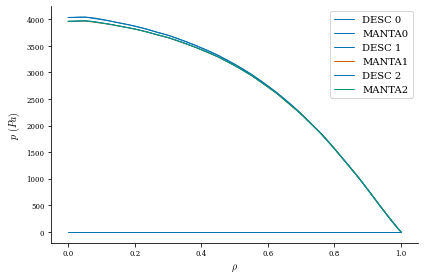

In [3]:

solver_config = {
    "OutputFilename": fname,
    "RestartFile": "stellarator_opt0.restart.nc",
    "Polynomial_degree": 3,
    "Grid_size": 4,
    "tau": 1.0, 
    "Lower_boundary": 0.0,
    "Upper_boundary": rho_upper,
    "Relative_tolerance": rtol,
    "Absolute_tolerance": [atol],
    "delta_t": 1e-2,
    "initialTimestep": 1e-5,
    "MinStepSize": 1e-10,
    "restart": True,
    "solveAdjoint": True, 
    "zeroFlux": True,
    "SteadyStateTolerance": 1e-4,
}

config = {
    "Stellarator": st_config,
    "Solver": solver_config,
}

fig, ax = plt.subplots()

eq2 = eq.copy()
fam2 = EquilibriaFamily(eq2)
niters = 2
for k in range(niters):
    eq2 = eq2.copy()

    fig, ax = plot_1d(eq2, "pressure", label="DESC " + str(k), ax=ax)

    yancc_wrapper = yancc_data.from_eq(points, eq=eq2, nt = yancc_ntheta, nz = yancc_nzeta, **yancc_res)
    pressure_rho = jnp.concatenate([jnp.zeros(1), yancc_rho, jnp.ones(1)])
    st = StellaratorTransport(config, yancc_wrapper=yancc_wrapper)
    st.run()
    
    pi = st.getPressure()
    
    print(pi)
    pi_manta = jnp.concatenate([jnp.array([pi[0]]), pi, jnp.zeros(1)])
    ax.plot(pressure_rho, pi_manta, label="MANTA" + str(k))
    eq2.pressure = SplineProfile(pi_manta, pressure_rho)
    # fit the current profile to a power series, with c_0=c_1=0
    # XX = np.fliplr(np.vander(rho, eq2.L + 1)[:, :-2])
    # eq2.c_l = np.pad(np.linalg.lstsq(XX, current, rcond=None)[0], (2, 0))
    # re-solve the equilibrium
    eq2, _ = eq2.solve(objective="force", optimizer="lsq-exact", verbose=3)
    fam2.append(eq2)

eq_self_consistent = eq2.copy()

ax.legend()

(<Figure size 864x720 with 6 Axes>,
 array([<Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.000$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>,
        <Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.167$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>,
        <Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.333$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>,
        <Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.500$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>,
        <Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.667$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>,
        <Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.833$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>],
       dtype=object))

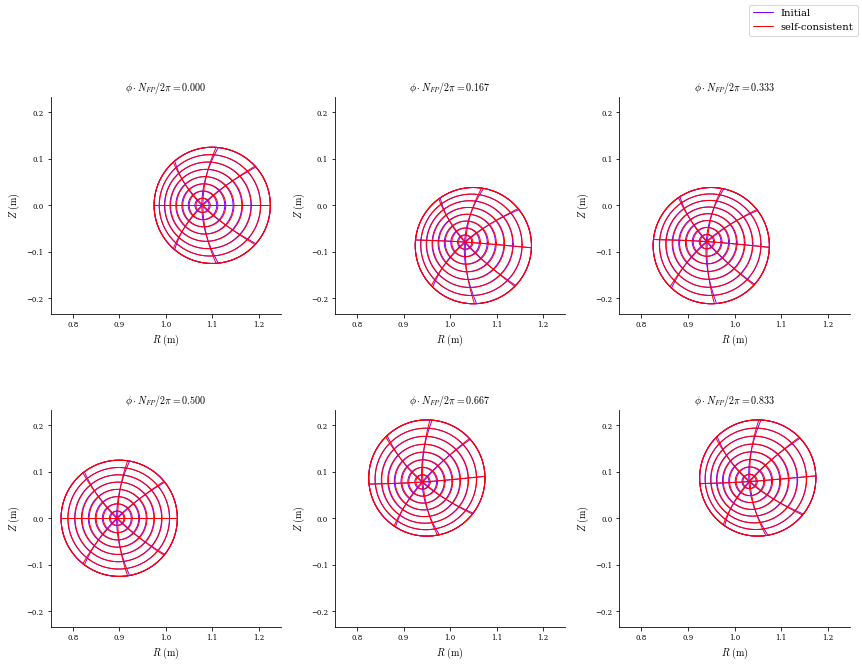

In [4]:
from desc.plotting import plot_comparison

plot_comparison(
    eqs=[eq_init, eq2], labels=["Initial", "self-consistent"]
)

In [5]:
eq = eq2.copy()


In [6]:
solver_config = {
    "OutputFilename": fname,
    "Polynomial_degree": 3,
    "Grid_size": 4,
    "tau": 1.0, 
    "Lower_boundary": 0.0,
    "Upper_boundary": rho_upper,
    "Relative_tolerance": rtol,
    "Absolute_tolerance": [atol],
    "delta_t": 0.001,
    "initialTimestep": 1e-5,
    "MinStepSize": 1e-10,
    "restart": True,
    "solveAdjoint": True, 
    "zeroFlux": True,
    "SteadyStateTolerance": 1e-4,
}
config = {
    "Stellarator": st_config,
    "Solver": solver_config,
}

manta_objective = make_objective(config, yancc_res=yancc_res)

# def manta_yancc_fun(fields, grid, Vprime):

#     stored_energy, pressure = Objective(fields, grid, Vprime) 

#     return stored_energy, pressure

def objective_from_user_fun(grid, data):
  # note: don't change the signature to this function
    yancc_dat = {
        "B_sup_t": data["B^theta"],
        "B_sup_z": data["B^zeta"],
        "B_sub_t": data["B_theta"],
        "B_sub_z": data["B_zeta"],
        "Bmag": data["|B|"],
        "dBdt": data["|B|_t"],
        "dBdz": data["|B|_z"],
        "sqrtg": data["sqrt(g)"],
    }

    yancc_dat = {
        key: grid.meshgrid_reshape(val, "rtz") for key, val in yancc_dat.items()
    }

    yancc_dat["Psi"] = grid.compress(
        data["Psi"] / grid.nodes[:, 0] ** 2, surface_label="rho"
    )
    yancc_dat["a_minor"] = jnp.full(grid.num_rho, data["a"])
    yancc_dat["R_major"] = jnp.full(grid.num_rho, data["R0"])
    yancc_dat["iota"] = grid.compress(data["iota"], surface_label="rho")
    yancc_dat["rho"] = grid.compress(grid.nodes[:, 0], surface_label="rho")

    V = grid.compress(data['V(r)'])
    V_r = grid.compress(data['V_r(r)'])
    V_rr = grid.compress(data['V_rr(r)'])
    Vp = V_r/V[-1]
    Vpp = V_rr/V[-1]
    
    fields = jax.vmap(lambda d: yancc.field.Field(**d, NFP=grid.NFP))(yancc_dat)

    desc_pressure = grid.compress(data["p"], surface_label="rho")
    
    stored_energy, manta_pressure = manta_objective((fields, Vp, Vpp), grid)
    print("------------ STORED ENERGY ----------------")
    print(stored_energy)
    print("-------------------------------------------")
    
    pressure_error = manta_pressure - desc_pressure # not sure if the sign makes the difference here

    print("------------TOTAL PRESSURE ERROR-----------")
    print(pressure_error)
    print("-------------------------------------------")

    # optimization is easiest for least squares objectives, so instead of maximizing
    # stored energy we minimize 1/stored_energy^2 (the squaring happens later)
    return 1 / stored_energy #jnp.append(pressure_error, 1 / stored_energy)

yancc_desc_grid = yancc_wrapper.grid

# domain_boundary_rho = rho_from_normalized_volume(0.9)
domain_boundary_rho = 1.0
def pressure_constraint_fun(params):
    # function to fix dp/dr=0 at axis and p=0 at edge
    # can modify this for other BC (eg fix p at rho=0.8)
    p_l = params["p_l"]
    dp0 = desc_pressure(Grid(jnp.zeros((1, 3)), jitable=True), p_l, dr=1)
    p1 = desc_pressure(Grid(jnp.zeros((1, 3)).at[0, 0].set(domain_boundary_rho), jitable=True), p_l)
    return jnp.array([dp0, p1]).squeeze()

pi_edge = st.getPressure([1.0])[0]
pressure_constraint_target = jnp.array([0.0, pi_edge])

In [7]:

pressure_error_weight = jnp.full(yancc_desc_grid.num_rho, 1e-6)
stored_energy_weight = 1.0
# jnp.append(stored_energy_weight)
objective_from_user_weight = stored_energy_weight
fig, ax = plt.subplots()
max_it = 8

eqfam = EquilibriaFamily(eq)
ks = [1, 2, eq.M + 1]
for k in ks: 
    print("\n==================================")
    print("Optimizing boundary modes M,N <= {}".format(k))
    print("====================================")

    objectives = [
        # AspectRatio(eq=eq, target=6, weight=10),
        Volume(eq=eqfam[-1], target=V0, weight=0.5),
        # RotationalTransform(eq=eq, target=0.42, weight=10),
        ObjectiveFromUser(
            objective_from_user_fun,
            eqfam[-1],
            target=0,
            weight=objective_from_user_weight,
            grid=yancc_desc_grid,
            deriv_mode="fwd",
            # need this assuming manta only has vjp, if using jvp switch to fwd
        ),
    ]

    objective = ObjectiveFunction(objectives)
    objective.build(use_jit=False)


    R_modes = np.vstack(
        (
            [0, 0, 0],
            eq.surface.R_basis.modes[
                np.max(np.abs(eq.surface.R_basis.modes), 1) > k, :
            ],
        )
    )
    Z_modes = eq.surface.Z_basis.modes[
        np.max(np.abs(eq.surface.Z_basis.modes), 1) > k, :
    ]
    constraints = [
        ForceBalance(eq=eqfam[-1]),  # J x B - grad(p) = 0
        # fix zero current, eventually should use real bootstrap
        FixCurrent(eq=eqfam[-1]),
        # Volume(eq=eq, target=V0), # fix volume of outer flux surface
        FixBoundaryR(eq=eqfam[-1], modes=R_modes),
        FixBoundaryZ(eq=eqfam[-1], modes=Z_modes),
        FixPsi(eq=eqfam[-1]),  # fix total magnetic flux
        LinearObjectiveFromUser(
            pressure_constraint_fun, eqfam[-1], target=pressure_constraint_target
        ),
    ]
    # print(objective.jac_scaled(objective.x(eq)))
    eq_out, info_out = eqfam[-1].optimize(
        objective=objective,
        constraints=constraints,
        optimizer="proximal-lsq-exact",
        x_scale="ess",
        maxiter=max_it,
        ftol=1e-3,  # stopping tolerance on the function value
        xtol=1e-6,  # stopping tolerance on the step size
        gtol=1e-6,  # stopping tolerance on the gradient
        # options={
        #     "initial_trust_radius": 5e-4,
        #     "perturb_options": {"order": 2, "verbose": 3},  # use 2nd-order perturbations
        # #     # "solve_options": {
        # #     #     "ftol": 5e-3,
        # #     #     "xtol": 1e-6,
        # #     #     "gtol": 1e-6,
        # #     #     "verbose": 3,
        #     # },  # for equilibrium subproblem
        # },
        verbose=3,
        copy=True,
    )

    # %%
    eqfam.append(eq_out.copy())

/tmp/ipykernel_1075591/3332977704.py:24: DeprecationWarning: vstack requires ndarray or scalar arguments, got <class 'list'> at position 0. In a future JAX release this will be an error.
  R_modes = jnp.vstack(


Building objective: volume
Precomputing transforms
Building objective: Custom
Flux norm : JitTracer(~float64[])
yancc_wrapper initialized successfully with resolution na=43, nx=5.
configuring
Successfully created StellaratorTransport object
------------ STORED ENERGY ----------------
JitTracer(float32[])
-------------------------------------------
------------TOTAL PRESSURE ERROR-----------
JitTracer(float64[20])
-------------------------------------------
Building objective: force
Precomputing transforms


Total HDG degrees of freedom 65
Configuration done.


Timer: Precomputing transforms = 98.1 ms
Timer: Objective build = 109 ms
Timer: Objective build = 1.74 ms
Timer: Eq Update LinearConstraintProjection build = 56.5 ms
Timer: Proximal projection build = 3.99 sec
Building objective: fixed current
Building objective: fixed Psi
Building objective: custom linear
Timer: Objective build = 2.17 sec
Timer: LinearConstraintProjection build = 4.80 sec
Number of parameters: 101
Number of objectives: 2
Timer: Initializing the optimization = 11.6 sec

Starting optimization
Using method: proximal-lsq-exact
Flux norm : 146419.5551768456
yancc_wrapper initialized successfully with resolution na=43, nx=5.
configuring
Successfully created StellaratorTransport object


Total HDG degrees of freedom 65
Configuration done.
Setting initial conditions
Residual norm at t = 0: 0
Residual norm at t = 0: inf
Residual norm at t = 0: inf
Residual norm at t = 0: 0.0407255


...

INFO: Computing adjoints for 2972 parameters
Successfully computed dgdp
2972
20


Done.
(20, 2972)
(20, 2972)
------------ STORED ENERGY ----------------
JVPTracer(primal=0.55256116, tangent=VmapTracer(aval=float32[], batched=float32[101]))
-------------------------------------------
------------TOTAL PRESSURE ERROR-----------
JVPTracer(primal=[5677.96054092 5689.21683745 5716.19868816 5734.09267668 5732.6875185
 5728.86421374 5710.71790432 5639.26621106 5505.47497573 5381.80577276
 5343.17865941 5172.45266936 4804.15291446 4298.37405106 3902.34969244
 3785.81306021 3289.79522386 2322.28855959 1088.64993781  148.39738811], tangent=VmapTracer(aval=float64[20], batched=float64[101,20]))
-------------------------------------------
       6             10          1.635e+00      7.875e-03      1.376e-04      4.001e+01   
Flux norm : 146419.5551768456
yancc_wrapper initialized successfully with resolution na=43, nx=5.
configuring
Successfully created StellaratorTransport object


Total HDG degrees of freedom 65
Configuration done.
Setting initial conditions
Residual norm at t = 0: 0
Residual norm at t = 0: inf
Residual norm at t = 0: 0
Residual norm at t = 0: 0.0445569


Number of Residual Evaluations due to IDACalcIC 3


Residual norm at t = 0: 0.684677
Residual norm at t = 1e-05: 0
Residual norm at t = 1e-05: 0.0549393
Residual norm at t = 2e-05: 0.000106993
Residual norm at t = 4e-05: 0.0529836
Residual norm at t = 4e-05: 0.187071
Residual norm at t = 8e-05: 0.0275194
Residual norm at t = 8e-05: 0.0315808
Residual norm at t = 0.00016: 9.80285e-05
Residual norm at t = 0.00032: 0.0162932
Residual norm at t = 0.00064: 0.0138943

KeyboardInterrupt



In [ ]:
eq = eq_out.copy()

# final self consistency 
fig, ax = plt.subplots()
niters = 2
for k in range(niters):
    eq = eq.copy()

    fig, ax = plot_1d(eq, "pressure", label="DESC " + str(k), ax=ax)

    yancc_wrapper = yancc_data.from_eq(points, eq=eq, nt = yancc_ntheta, nz = yancc_nzeta)
 
    st = StellaratorTransport(config, yancc_wrapper=yancc_wrapper)
    st.run()
    
    pi = st.getPressure()

    pi_manta = jnp.concatenate([jnp.array([pi[0]]), pi, jnp.zeros(1)])
    ax.plot(pressure_rho, pi_manta, label="MANTA" + str(k))
    eq.pressure = SplineProfile(pi_manta, pressure_rho)
    # fit the current profile to a power series, with c_0=c_1=0
    
    # XX = np.fliplr(np.vander(rho, eq2.L + 1)[:, :-2])
    # eq2.c_l = np.pad(np.linalg.lstsq(XX, current, rcond=None)[0], (2, 0))
    # re-solve the equilibrium
    eq, _ = eq.solve(objective="force", x_scale ="ess", optimizer="lsq-exact", verbose=3)


ax.legend()
eq_optimized_self_consistent = eq.copy()

In [ ]:
eq_optimized_self_consistent.save(eq_name + "optimized_equilibrium.h5")

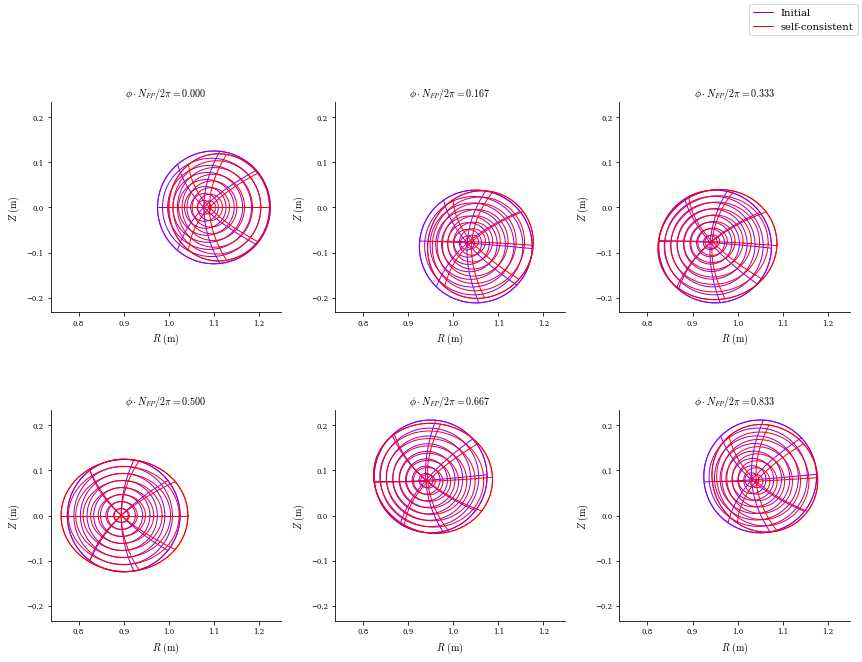

In [8]:
from desc.plotting import plot_comparison

plot_comparison(
    eqs=[eq_init, eq], labels=["Initial", "self-consistent"]
);

In [ ]:


fig, ax = plot_comparison(
    eqs=[eq_init, eqfam[-1]], labels=[
        "Initial", "self-consistent"]
)
fig.savefig("final_comparison.png")

In [ ]:
plot_boundaries(
    eqs=[eq_init, eq_optimized, eq], labels=["Initial", "optimized", "self-consistent"]
);

In [ ]:

# eq = desc.io.load("../python/eq2optimized_equilibrium.h5")#desc.examples.get("ESTELL")
# plot_boozer_surface(eq_init, fieldlines=8)
plot_boozer_surface(eq, fieldlines=8)
# plot_qs_error(eq_init)
plot_qs_error(eq)